# Sales Data Analysis

## Business Problem
How can a retail business improve profitability while maintaining strong sales performance?

## Objective
Analyze sales, profit, and discount patterns to identify key insights and recommendations.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Data Understanding
Exploring dataset structure, data types, and summary statistics.

In [32]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ship Mode      9994 non-null   str    
 1   Segment        9994 non-null   str    
 2   Country        9994 non-null   str    
 3   City           9994 non-null   str    
 4   State          9994 non-null   str    
 5   Postal Code    9994 non-null   int64  
 6   Region         9994 non-null   str    
 7   Category       9994 non-null   str    
 8   Sub-Category   9994 non-null   str    
 9   Sales          9994 non-null   float64
 10  Quantity       9994 non-null   int64  
 11  Discount       9994 non-null   float64
 12  Profit         9994 non-null   float64
 13  Profit Margin  9994 non-null   float64
dtypes: float64(4), int64(2), str(8)
memory usage: 1.1 MB


,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896,0.120314
std,32063.693350,623.245101,2.225110,0.206452,234.260108,0.466754
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-2.750000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750,0.075000
50%,56430.500000,54.490000,3.000000,0.200000,8.666500,0.270000
75%,90008.000000,209.940000,5.000000,0.200000,29.364000,0.362500
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000,0.500000


## Data Cleaning
Checking for missing values and preparing data for analysis.

In [24]:
df.isnull().sum()

Ship Mode        0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Category         0
Sub-Category     0
Sales            0
Quantity         0
Discount         0
Profit           0
Profit Margin    0
dtype: int64

In [25]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_discount = df['Discount'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Average Discount:", avg_discount)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Average Discount: 0.1562027216329798


## Exploratory Data Analysis

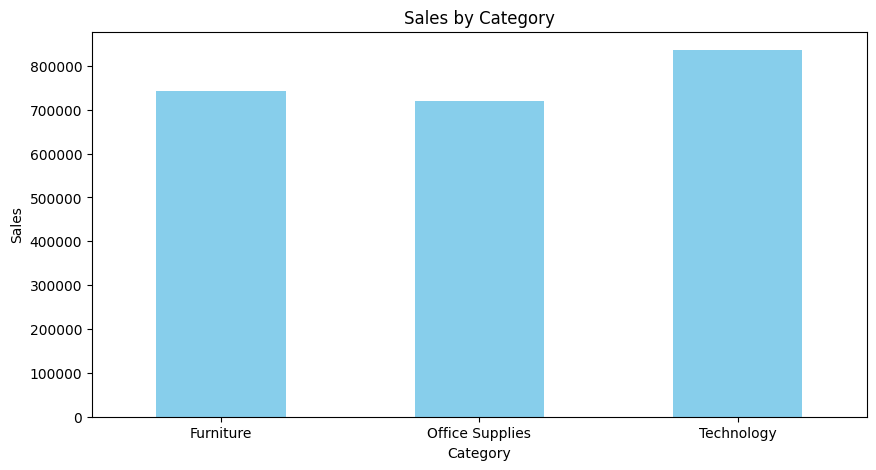

In [33]:
plt.figure(figsize=(10,5))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

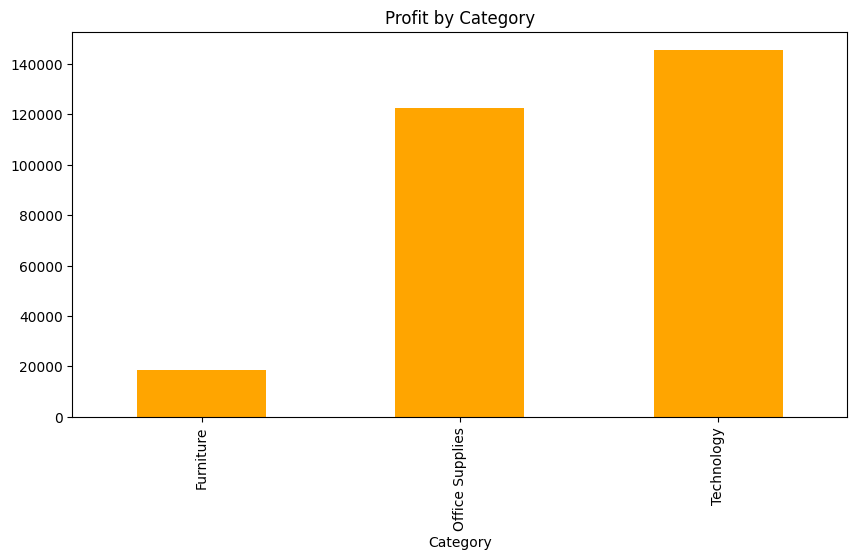

In [27]:
profit_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(10,5))
profit_category.plot(kind='bar', color='orange')
plt.title('Profit by Category')
plt.show()

In [ ]:
## Advanced Analysis

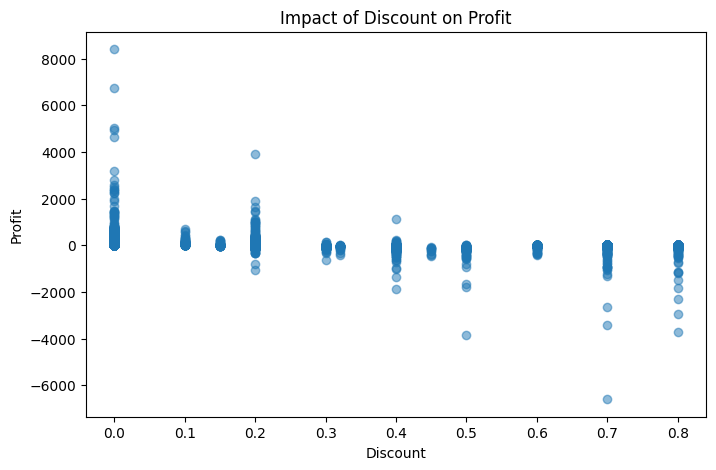

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

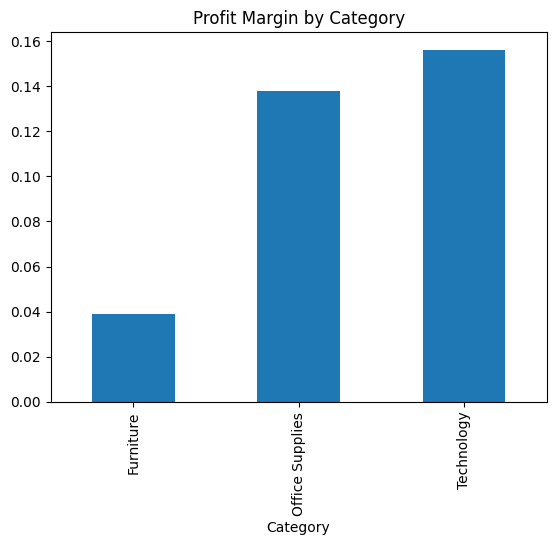

In [37]:
df['Profit Margin'] = df['Profit'] / df['Sales'].replace(0,1)

margin = df.groupby('Category')['Profit Margin'].mean()

margin.plot(kind='bar', title='Profit Margin by Category')
plt.show()

In [30]:
loss_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)
loss_sub

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

## Key Findings

- A clear negative correlation is observed between discount levels and profitability.

In [13]:
loss_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)
loss_sub

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

In [14]:
df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False).head(10)

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Name: Discount, dtype: float64

## Insights

- West region generates the highest profit, followed by East.
- The central region shows the lowest profitability and needs improvement.
- Some sub-categories have high sales but low or negative profit.
- Higher discounts are reducing overall profit margins.
- A few sub-categories contribute most of the revenue.

In [20]:
loss_orders = df[df['Profit'] < 0]

loss_orders.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)

Sub-Category
Binders     -38510.4964
Tables      -32412.1483
Machines    -30118.6682
Bookcases   -12152.2060
Chairs       -9880.8413
Name: Profit, dtype: float64

In [ ]:
## Key Insights

- Technology category generates the highest sales and profit  
- Some sub-categories have high sales but low or negative profit  
- Higher discounts negatively impact profitability  
- A small number of sub-categories contribute most revenue  
- Central region shows lower profitability  

In [ ]:
## Recommendations

- Reduce excessive discounts on low-margin products  
- Focus on high-profit categories  
- Improve performance in low-profit regions  
- Optimize pricing strategy  

In [ ]:
## Business Problem

The retail business is generating strong sales but facing inconsistent profitability. The objective is to identify key factors such as discount strategies and product performance that impact profit and provide actionable insights to improve efficiency. 

In [ ]:
## Conclusion

## Conclusion

The analysis shows that while sales performance is strong, profitability is significantly affected by discount strategies and underperforming sub-categories. By optimizing discounts and focusing on high-margin products, the business can improve overall financial performance.